<a href="https://colab.research.google.com/github/mohammad64874-boop/ml-student-performance/blob/main/ML_Lab_Project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
data = {
    'study_hours': [1,2,3,4,5,6,7,8,2,3,4,5,6,7,8],
    'attendance': [50,60,65,70,75,80,85,90,55,65,70,75,80,85,90],
    'previous_score': [40,45,50,55,60,65,70,75,42,52,58,63,67,72,78],
    'sleep_hours': [4,5,6,6,7,7,8,8,5,6,6,7,7,8,8],
    'pass': [0,0,0,0,1,1,1,1,0,0,1,1,1,1,1]
}

df = pd.DataFrame(data)
df.head()

,study_hours,attendance,previous_score,sleep_hours,pass
0,1,50,40,4,0
1,2,60,45,5,0
2,3,65,50,6,0
3,4,70,55,6,0
4,5,75,60,7,1


In [12]:
print(df.shape)
print(df.info())
print(df.describe())
print(df.isnull().sum())

(15, 5)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15 entries, 0 to 14
Data columns (total 5 columns):
 #   Column          Non-Null Count  Dtype
---  ------          --------------  -----
 0   study_hours     15 non-null     int64
 1   attendance      15 non-null     int64
 2   previous_score  15 non-null     int64
 3   sleep_hours     15 non-null     int64
 4   pass            15 non-null     int64
dtypes: int64(5)
memory usage: 732.0 bytes
None
       study_hours  attendance  previous_score  sleep_hours       pass
count    15.000000   15.000000       15.000000    15.000000  15.000000
mean      4.733333   73.000000       59.466667     6.533333   0.600000
std       2.250926   12.363541       11.993252     1.245946   0.507093
min       1.000000   50.000000       40.000000     4.000000   0.000000
25%       3.000000   65.000000       51.000000     6.000000   0.000000
50%       5.000000   75.000000       60.000000     7.000000   1.000000
75%       6.500000   82.500000       68.5000

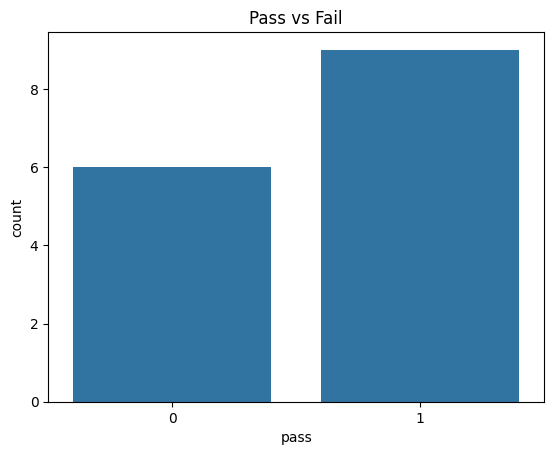

In [4]:
sns.countplot(x='pass', data=df)
plt.title("Pass vs Fail")
plt.show()

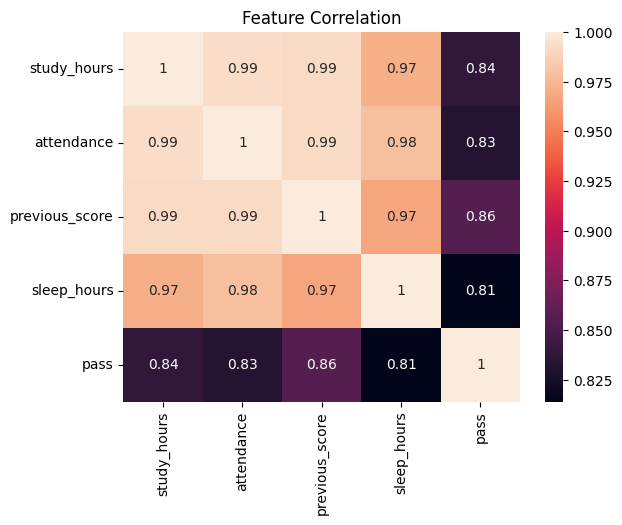

In [5]:
sns.heatmap(df.corr(), annot=True)
plt.title("Feature Correlation")
plt.show()

In [6]:
from sklearn.model_selection import train_test_split

X = df.drop('pass', axis=1)
y = df['pass']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [7]:
from sklearn.linear_model import LogisticRegression

lr = LogisticRegression()
lr.fit(X_train, y_train)

y_pred_lr = lr.predict(X_test)

In [8]:
from sklearn.tree import DecisionTreeClassifier

dt = DecisionTreeClassifier()
dt.fit(X_train, y_train)

y_pred_dt = dt.predict(X_test)

In [9]:
from sklearn.metrics import accuracy_score, confusion_matrix

print("Logistic Regression Accuracy:",
      accuracy_score(y_test, y_pred_lr))

print("Decision Tree Accuracy:",
      accuracy_score(y_test, y_pred_dt))

Logistic Regression Accuracy: 1.0
Decision Tree Accuracy: 1.0


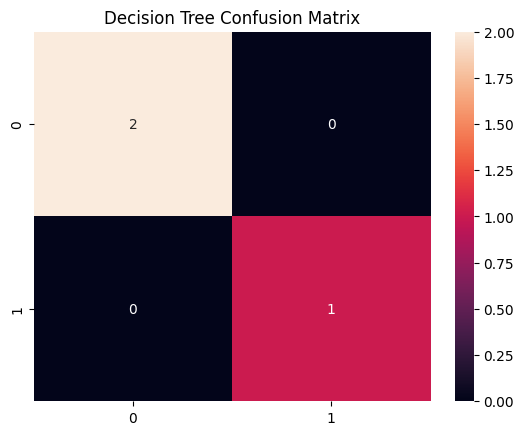

In [10]:
sns.heatmap(confusion_matrix(y_test, y_pred_dt),
            annot=True, fmt='d')
plt.title("Decision Tree Confusion Matrix")
plt.show()

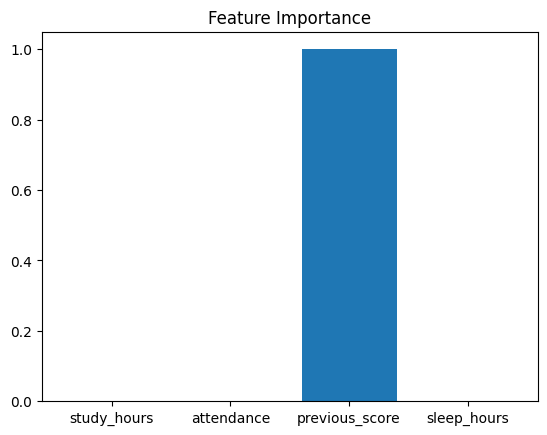

In [11]:
plt.bar(X.columns, dt.feature_importances_)
plt.title("Feature Importance")
plt.show()